In [42]:
import scipy.io
import numpy as np
from collections import Counter
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
# Convert networkx graphs to PyTorch Geometric Data objects
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, GCNConv, GATConv, SAGEConv, global_add_pool
import torch.nn as nn
import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, ChebConv, SAGEConv, global_mean_pool
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import networkx as nx
# import bct

In [ ]:
mat_data = scipy.io.loadmat('ranked_features.mat')
ranked_features = mat_data['ranked_features']

In [4]:
ranked_features.shape

(1152, 22, 17)

In [56]:
ranked_features_5 = ranked_features[:,:,:10]

In [57]:
ranked_features_5.shape

(1152, 22, 10)

In [58]:
num_samples,num_channels,num_features = ranked_features_5.shape

In [59]:
ranked_features_5_reshaped = ranked_features_5.reshape(num_samples, num_channels * num_features)

In [60]:
pca = PCA(n_components=min(num_samples, num_channels * num_features))  # Choose the max possible components
pca_result = pca.fit_transform(ranked_features_5_reshaped)

In [17]:
import numpy as np
import mne
import h5py
from scipy.stats import spearmanr

def extract_filtered_eeg(i):
    """ Load, preprocess EEG data, and extract connectivity features. """

    raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A0{i}T.gdf',
                              eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
    raw.set_eeg_reference()

    channel_rename_dict = {
        'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
        'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4',
        'EEG-8': 'C6', 'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
        'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'
    }
    raw.rename_channels(channel_rename_dict)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))

    events, event_id = mne.events_from_annotations(raw)
    epoch = mne.Epochs(raw, events, event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, preload=True)

    labels = epoch.events[:, -1] - 7
    labels = np.array(labels)  # Ensure labels are NumPy array
    epoch.apply_baseline((-1.5, 0.0))
    file_path = f'/Users/siddharth/Documents/Brainconnectivity/filtered_Artifacts_removed/filt_PreProc_EEG_ICA_filt_sub{i}.mat'
    
    def recursive_get_data(group, file):
        """ Recursively extract HDF5 data. """
        data = {}
        for key in group:
            item = group[key]
            if isinstance(item, h5py.Group):
                data[key] = recursive_get_data(item, file)
            elif isinstance(item, h5py.Dataset):
                data[key] = item[:]
            elif isinstance(item, h5py.Reference):
                ref_obj = file[item]
                if isinstance(ref_obj, h5py.Dataset):
                    data[key] = ref_obj[:]
                elif isinstance(ref_obj, h5py.Group):
                    data[key] = recursive_get_data(ref_obj, file)
        return data

    with h5py.File(file_path, 'r') as f:
        all_data = recursive_get_data(f, f)

    eeg_data = []
    for key in all_data.get('#refs#', {}):
        ref_group = all_data['#refs#'][key]
        if ref_group.shape[0] == 751:
            eeg_data.append(ref_group)

    eeg_data = np.stack(eeg_data, axis=0).reshape(144, 22, 751)  # Adjust shape if needed

    return eeg_data, labels, epoch['769'].average()

In [18]:
import numpy as np

eeg_data = []
labels = []

for i in range(2, 10):
    i = 8 
    data, label, info = extract_filtered_eeg(i)
    
    eeg_data.append(data)  # Append EEG data for the current subject
    labels.append(label)    # Append labels for the current subject

eeg_data = np.array(eeg_data)  # Shape: (num_subjects, num_trials, num_channels, num_datapoints)
labels = np.array(labels)      # Shape: (num_subjects, num_trials)


eeg_data = eeg_data.reshape(-1, 22, eeg_data.shape[-1])  # Shape: (num_trials, num_channels, feature_dim)
labels = labels.reshape(-1)  # Shape: (num_trials, num_channels, feature_dim)

print("EEG Data Shape:", eeg_data.shape)  # Expected shape: (num_subjects, num_trials, num_channels, num_datapoints)
print("Labels Shape:", labels.shape)      # Expected shape: (num_subjects, num_trials)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
EEG Data Shape: (1152, 22, 751)
Labels Shape: (1152,)


In [19]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [20]:
import mne
import numpy as np
from mne_connectivity import spectral_connectivity_epochs

# Define EEG channel names
ch_names = [f'EEG{i+1}' for i in range(22)]
info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')

# Create MNE Epochs objects
epochs_0 = mne.EpochsArray(eeg_data_0, info)
epochs_1 = mne.EpochsArray(eeg_data_1, info)

# Define frequency range
fmin, fmax = 0.5, 48.0  

# Compute connectivity separately for each trial
n_trials = len(epochs_0)

# Initialize array to store per-trial connectivity
connectivity_0_trials = []
connectivity_1_trials = []

for trial in range(n_trials):
    con_0 = spectral_connectivity_epochs(
        epochs_0[trial],  # Process one trial at a time
        method='imcoh',       
        mode='multitaper',    
        sfreq=250,
        fmin=fmin,
        fmax=fmax,
        faverage=True,       
        mt_bandwidth=4.0,    
        n_jobs=-1
    ).get_data()
    
    con_1 = spectral_connectivity_epochs(
        epochs_1[trial],  # Process one trial at a time
        method='imcoh',       
        mode='multitaper',    
        sfreq=250,
        fmin=fmin,
        fmax=fmax,
        faverage=True,       
        mt_bandwidth=4.0,    
        n_jobs=-1
    ).get_data()

    connectivity_0_trials.append(con_0)
    connectivity_1_trials.append(con_1)

# Convert list to NumPy arrays
connectivity_0_trials = np.array(connectivity_0_trials)  # Shape: (72, 484, 1)
connectivity_1_trials = np.array(connectivity_1_trials)  # Shape: (72, 484, 1)

# Print the shapes
print("Connectivity_0 shape:", connectivity_0_trials.shape)
print("Connectivity_1 shape:", connectivity_1_trials.shape)

Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:24: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:36: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


...

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:24: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5

Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connecti

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:36: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5

    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    compu

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:36: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:36: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_66111/1784859665.py:24: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5

In [36]:
connectivity_0_trials = connectivity_0_trials.reshape(576,22,22)
connectivity_1_trials = connectivity_1_trials.reshape(576,22,22)

In [69]:
features = np.array(ranked_features_5)

In [70]:
labels = labels.reshape(-1)

In [71]:
import numpy as np
import networkx as nx
import scipy.io
from scipy import stats

def create_graphs_with_edge_indicator(features, labels, connectivity_0_trials, connectivity_1_trials):
    graphs = []
    unique_labels = np.unique(labels)

    # Combine all connectivity trials
    all_connectivity = np.concatenate([connectivity_0_trials, connectivity_1_trials], axis=0)
    all_labels = np.concatenate([np.zeros(connectivity_0_trials.shape[0]), np.ones(connectivity_1_trials.shape[0])])

    num_nodes = connectivity_0_trials.shape[1]  # Should be 22
    # Construct graphs for each trial
    for trial_idx in range(all_connectivity.shape[0]):
        G = nx.Graph()
        current_label = all_labels[trial_idx]
        current_features = features[trial_idx]  # Shape (22, feature_dim)
        current_connectivity = all_connectivity[trial_idx]  # Shape (22,22)

        # Add nodes with features
        for node in range(num_nodes):
            G.add_node(node, features=current_features[node, :])

        # Add edges based on significance
        for i in range(num_nodes):
            for j in range(num_nodes):
                # if edge_indices[i, j] and i != j:  # Add only significant edges
                if i!=j:
                    edge_weight = current_connectivity[i, j]
                    G.add_edge(i, j, weight=edge_weight)

        graphs.append(G)

    return graphs

In [72]:
graphs = create_graphs_with_edge_indicator(features, labels, connectivity_0_trials, connectivity_1_trials)


In [73]:
from sklearn.model_selection import train_test_split

# Split the graphs and labels
train_graphs, test_graphs, train_labels, test_labels = train_test_split(
    graphs, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train set: {len(train_graphs)} graphs")
print(f"Test set: {len(test_graphs)} graphs")

Train set: 921 graphs
Test set: 231 graphs


In [74]:
def graph_to_data(graph, label):
    # Get edge indices
    edge_index = torch.tensor(list(graph.edges), dtype=torch.long).t().contiguous()
    
    # Get edge weights (connectivity values)
    edge_weights = torch.tensor([graph.edges[e]['weight'] for e in graph.edges()], dtype=torch.float)
    
    # Get node features
    node_features = torch.tensor([graph.nodes[node]['features'] for node in graph.nodes], dtype=torch.float)

    # Create data object with edge attributes
    data = Data(
        x=node_features, 
        edge_index=edge_index, 
        edge_attr=edge_weights,  # Add this line
        y=torch.tensor(label, dtype=torch.long)
    )
    return data

# Create list of Data objects
data_list_train = [graph_to_data(graph, train_labels[i]) for i, graph in enumerate(train_graphs)]
data_list_test = [graph_to_data(graph, test_labels[i]) for i, graph in enumerate(test_graphs)]


train_loader = DataLoader(data_list_train, batch_size=1, shuffle=True)
test_loader = DataLoader(data_list_test, batch_size=1, shuffle=False)

In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, ChebConv, SAGEConv, global_mean_pool

class GraphConvBlock(nn.Module):
    """Block with two GraphConv layers in series and global mean pooling."""
    def __init__(self, in_channels, hidden_channels):
        super(GraphConvBlock, self).__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Norm after first layer
        self.conv2 = GraphConv(hidden_channels, hidden_channels//2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = global_mean_pool(x, batch)  # Graph-level feature
        return x

class ChebConvBlock(nn.Module):
    """Block with two ChebConv layers in series and global mean pooling."""
    def __init__(self, in_channels, hidden_channels, K=2):
        super(ChebConvBlock, self).__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Norm after first layer
        self.conv2 = ChebConv(hidden_channels, hidden_channels//2, K)  # Integer division

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = global_mean_pool(x, batch)  # Graph-level feature
        return x

class SAGEConvBlock(nn.Module):
    """Block with two SAGEConv layers in series and global mean pooling."""
    def __init__(self, in_channels, hidden_channels):
        super(SAGEConvBlock, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # Batch Norm after first layer
        self.conv2 = SAGEConv(hidden_channels, hidden_channels//2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = global_mean_pool(x, batch)  # Graph-level feature
        return x

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=20):
        super(GCN, self).__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels*3, out_channels)  # Updated input size

    def forward(self, x, edge_index, edge_weight, batch):
        graph_features = self.graph_block(x, edge_index, edge_weight, batch)
        cheb_features = self.cheb_block(x, edge_index, edge_weight, batch)
        sage_features = self.sage_block(x, edge_index, edge_weight, batch)
        x = torch.cat([graph_features, cheb_features, sage_features], dim=1)  # Concatenation
        x = self.fc(x)  # Classification layer
        return x
    
gcn_model = GCN(in_channels=10, hidden_channels=20, out_channels=2, K=2)
print(gcn_model)

GCN(
  (graph_block): GraphConvBlock(
    (conv1): GraphConv(10, 20)
    (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): GraphConv(20, 10)
  )
  (cheb_block): ChebConvBlock(
    (conv1): ChebConv(10, 20, K=2, normalization=sym)
    (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): ChebConv(20, 10, K=2, normalization=sym)
  )
  (sage_block): SAGEConvBlock(
    (conv1): SAGEConv(10, 20, aggr=mean)
    (bn1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): SAGEConv(20, 10, aggr=mean)
  )
  (fc): Linear(in_features=60, out_features=2, bias=True)
)


In [83]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, global_mean_pool

class SimpleGraphClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super(SimpleGraphClassifier, self).__init__()
        # A single GraphConv layer to compute node embeddings.
        self.conv = GraphConv(in_channels, hidden_channels)
        # A linear layer that maps the pooled graph representation to the output classes.
        self.fc = nn.Linear(hidden_channels, num_classes)
    
    def forward(self, x, edge_index, batch):
        # Apply the GraphConv layer and activation.
        x = self.conv(x, edge_index)
        x = F.relu(x)
        # Aggregate node features into a graph-level feature via global mean pooling.
        x = global_mean_pool(x, batch)
        # Final classification layer.
        x = self.fc(x)
        return x

# Example usage:
# Assume in_channels=5, we choose hidden_channels=16, and we have 2 classes.
gcn_model = SimpleGraphClassifier(in_channels=10, hidden_channels=16, num_classes=2)
print(gcn_model)


SimpleGraphClassifier(
  (conv): GraphConv(10, 16)
  (fc): Linear(in_features=16, out_features=2, bias=True)
)


In [84]:
import torch.optim as optim
train_accuracies = []
test_accuracies = []

# num_epochs = 50
# Define optimizer and loss
optimizer = torch.optim.AdamW(
    gcn_model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)
criterion = nn.CrossEntropyLoss()

# Train the gcn_model
def train():
    gcn_model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()  # Clear gradients
        out = gcn_model(data.x, data.edge_index, data.edge_weight, data.batch)  # Forward pass
        # print(out)
        loss = criterion(out, data.y)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        total_loss += loss.item()
    print(f"Train Loss: {total_loss / len(train_loader):.4f}")

# Test the gcn_model
def test(loader):
    gcn_model.eval()
    correct = 0
    for data in loader:
        out = gcn_model(data.x, data.edge_index, data.edge_weight, data.batch)
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset)

# Main training loop
num_epochs = 100
for epoch in range(num_epochs):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


TypeError: SimpleGraphClassifier.forward() takes 4 positional arguments but 5 were given

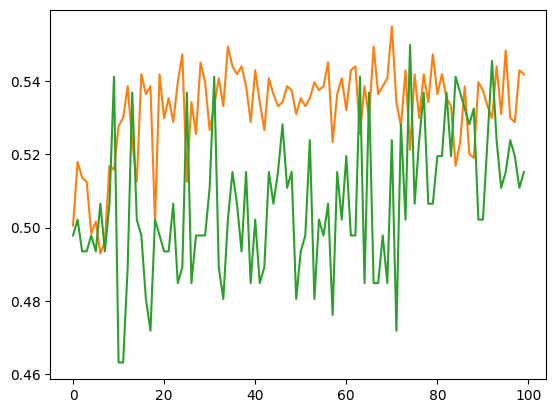

In [79]:
import matplotlib.pyplot as plt
plt.plot(train_loss, label='Train Loss')
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')